# Imports

In [77]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes



import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts, which stay as text
def curly_arrow(start, end, arr_size = 1, n = 5, col='gray', linew=1., width = 0.1):
    xmin, ymin = start
    xmax, ymax = end
    dist = np.sqrt((xmin - xmax)**2 + (ymin - ymax)**2)
    n0 = dist / (2 * np.pi)
    
    x = np.linspace(0, dist, 151) + xmin
    y = width * np.sin(n * x / n0) + ymin
    line = plt.Line2D(x,y, color=col, lw=linew)
    
    del_x = xmax - xmin
    del_y = ymax - ymin
    ang = np.arctan2(del_y, del_x)
    
    line.set_transform(mpl.transforms.Affine2D().rotate_around(xmin, ymin, ang) + ax.transData)
    ax.add_line(line)

    verts = np.array([[0,1],[0,-1],[2,0],[0,1]]).astype(float) * arr_size
    verts[:,1] += ymax
    verts[:,0] += xmax
    path = mpath.Path(verts)
    patch = mpatches.PathPatch(path, fc=col, ec=col)

    patch.set_transform(mpl.transforms.Affine2D().rotate_around(xmax, ymax, ang) + ax.transData)
    return patch


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Oldest living

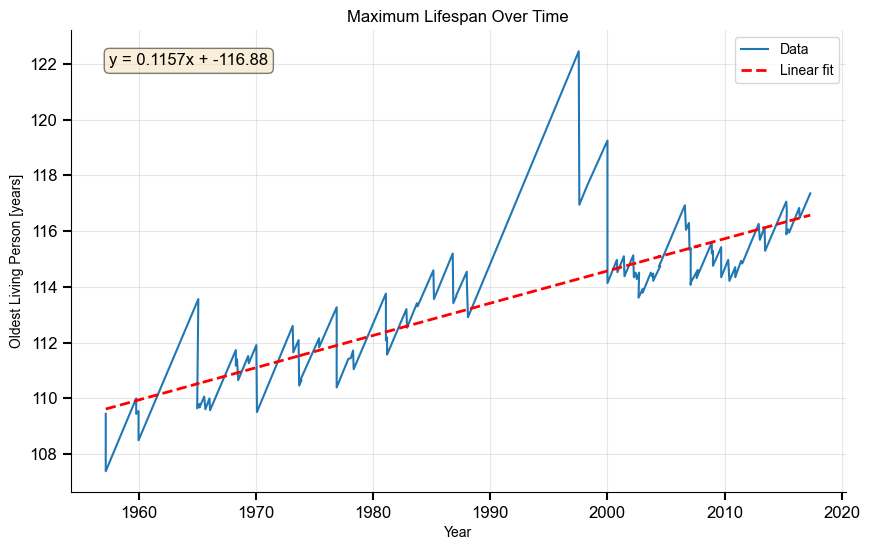

In [82]:
# Load and plot oldest living person data
df = pd.read_csv('saved_results/oldest_living_person.csv')
df.columns = ['year', 'oldest']
df.head()

# Fit linear trend line
z = np.polyfit(df['year'], df['oldest'], 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 6))
plt.plot(df['year'], df['oldest'], label='Data')
plt.plot(df['year'], p(df['year']), 'r--', linewidth=2, label='Linear fit')
plt.xlabel('Year')
plt.ylabel('Oldest Living Person [years]')
plt.title('Maximum Lifespan Over Time')
plt.grid(True, alpha=0.3)

# Add equation to plot
equation_text = f'y = {z[0]:.4f}x + {z[1]:.2f}'
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.legend()
plt.show()


# Max Lifespan vs N


## gaussian distribution in Xc

10
18
33
61
112
206
379
695
1274
2335
4281
7847
14384
26366
48329
88586
162377
297635
545559
Skipping population size 1000000 - larger than available data


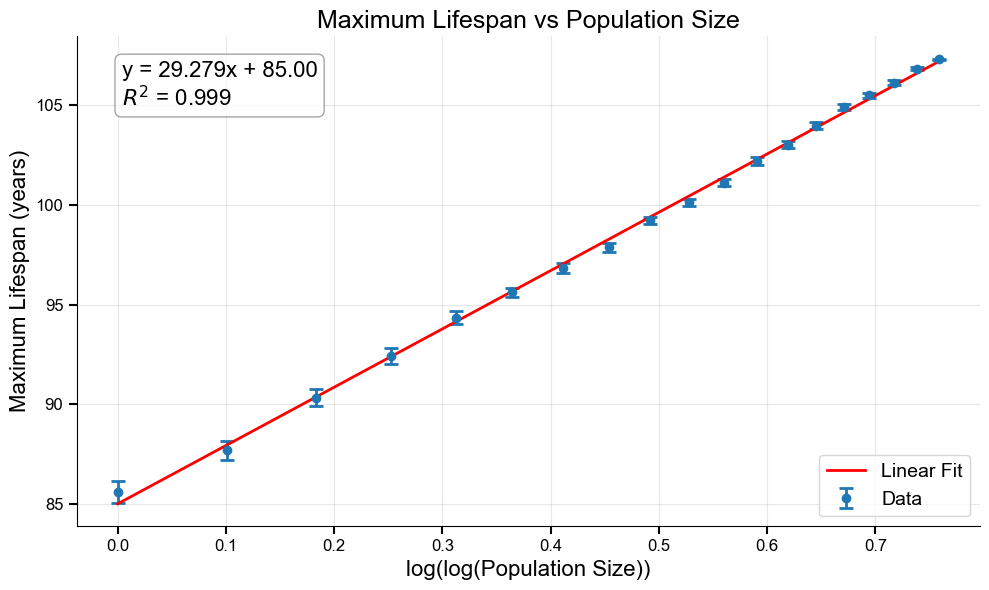

In [78]:
n_sim = int(1e6)
import sys
sys.path.append('../extrinsic_mortality_paper/data')
import model_param_calibrations as mcal

danish_dict = mcal.sr_denmark_dict.copy()
danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']
        
# Adjust Xc
danish_dict['Xc'] = 0.85 * danish_dict['Xc']

# Create parameter distributions
danish_param_dist = utils.create_param_distribution_dict(
    params_dict=danish_dict,
    params='Xc',
    std=danish_Xc_std,
    n=n_sim,
    family='None'
)

# Simulate
hum_sim = utils.create_sr_simulation(params_dict=danish_param_dist, n=n_sim, parallel = True)


pop_size = np.logspace(1, 6, 20)

# Sample maximum lifespans for different population sizes
max_lifespans = []
max_lifespans_sem = []

death_times = hum_sim.death_times[hum_sim.death_times <= 130]

# Pre-shuffle the death times once to avoid repeated sorting
shuffled_death_times = np.random.permutation(death_times)

for pop in pop_size:
    pop = int(pop)
    max_values = []
    
    # Skip if population size is larger than available data
    if pop > len(shuffled_death_times):
        print(f"Skipping population size {pop} - larger than available data")
        continue
    
    # Handle case where population equals available data
    if pop == len(shuffled_death_times):
        # Just take the maximum of all available data
        max_values = [np.max(shuffled_death_times)]
    else:
        # Repeat sampling 25 times for each population size
        for i in range(100):
            # Use different starting points in the shuffled array for each sample
            # Ensure we don't go out of bounds
            max_start_idx = len(shuffled_death_times) - pop
            if max_start_idx <= 0:
                start_idx = 0
            else:
                start_idx = (i * pop) % max_start_idx
            
            sampled_deaths = shuffled_death_times[start_idx:start_idx + pop]
            max_values.append(np.max(sampled_deaths))
    
    # Calculate mean and SEM
    mean_max = np.mean(max_values)
    sem_max = np.std(max_values) / np.sqrt(len(max_values))
    
    max_lifespans.append(mean_max)
    max_lifespans_sem.append(sem_max)
    
    print(pop)

import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set Arial font for all plot text and legend
plt.rcParams['font.family'] = 'Arial'

# Define x_array as log_log_N
x_array = np.log10(np.log10(pop_size[:len(max_lifespans)]))
y_array = np.array(max_lifespans)
yerr_array = np.array(max_lifespans_sem)

# Unweighted linear regression
X = x_array.reshape(-1, 1)
y = y_array

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

# Regression formula as string
slope = reg.coef_[0]
intercept = reg.intercept_
reg_formula = f"y = {slope:.3f}x + {intercept:.2f}\n$R^2$ = {r2:.3f}"

# Interpolating function: plug in N, get loglogN, then predicted max lifespan
def predict_max_lifespan(N):
    """
    Given population size N, returns predicted maximum lifespan using the fitted linear model.
    """
    loglogN = np.log10(np.log10(N))
    return slope * loglogN + intercept

# Example usage:
# predicted_lifespan = predict_max_lifespan(1e6)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(x_array, y_array, yerr=yerr_array, 
            marker='o', capsize=5, capthick=2, linewidth=2, label='Data', linestyle='None')

# Plot regression line
x_fit = np.linspace(x_array.min(), x_array.max(), 100)
y_fit = reg.predict(x_fit.reshape(-1, 1))
ax.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear Fit')

# Add regression formula as text
ax.text(0.05, 0.95, reg_formula, transform=ax.transAxes, fontsize=16, 
        verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

ax.set_xlabel('log(log(Population Size))', fontsize=16)
ax.set_ylabel('Maximum Lifespan (years)', fontsize=16)
ax.set_title('Maximum Lifespan vs Population Size', fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()


## FigA

/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_23846/2993868662.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


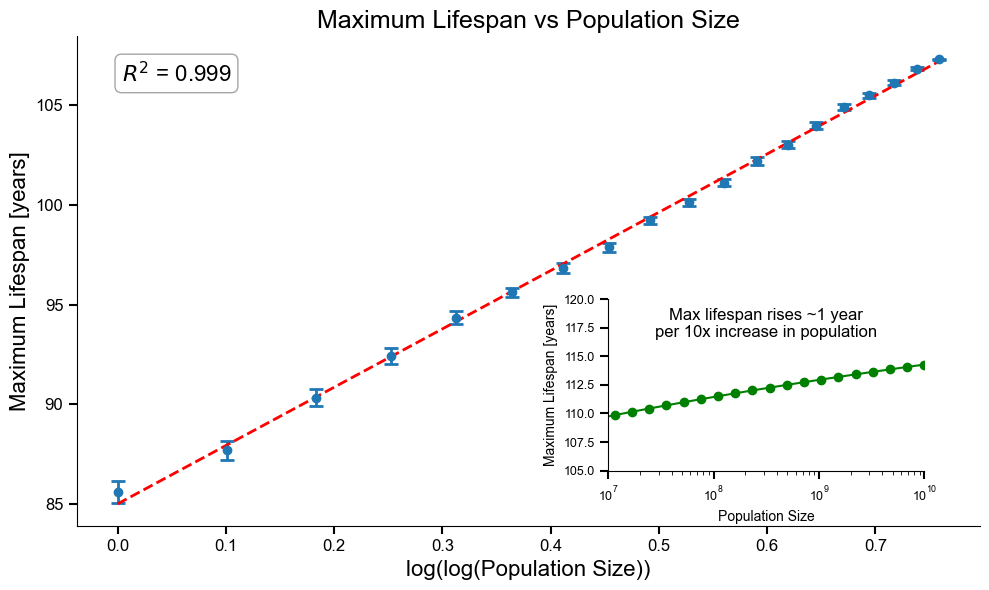

In [83]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(x_array, y_array, yerr=yerr_array, 
            marker='o', capsize=5, capthick=2, linewidth=2, linestyle='None')

# Plot regression line
x_fit = np.linspace(x_array.min(), x_array.max(), 100)
y_fit = reg.predict(x_fit.reshape(-1, 1))
ax.plot(x_fit, y_fit, color='red', linewidth=2, linestyle='--')

# Add R² as text
r2_text = f"$R^2$ = {r2:.3f}"
ax.text(0.05, 0.95, r2_text, transform=ax.transAxes, fontsize=16, 
        verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

ax.set_xlabel('log(log(Population Size))', fontsize=16)
ax.set_ylabel('Maximum Lifespan [years]', fontsize=16)
ax.set_title('Maximum Lifespan vs Population Size', fontsize=18)

# Create inset axes for the second plot
pops = np.logspace(np.log10(100), np.log10(1e10), 50)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ax_inset = inset_axes(ax, width="35%", height="35%", loc='lower right', borderpad=4)
ax_inset.plot(pops, predict_max_lifespan(pops), marker='o', linestyle='-', color='green')
ax_inset.set_xscale('log')
ax_inset.set_xlim(1e7, 1e10)
ax_inset.set_ylim(105, 120)
ax_inset.text(0.5, 0.95, 'Max lifespan rises ~1 year\nper 10x increase in population', 
              transform=ax_inset.transAxes, fontsize=12, ha='center', va='top')
ax_inset.set_xlabel('Population Size', fontsize=10)
ax_inset.set_ylabel('Maximum Lifespan [years]', fontsize=10)
ax_inset.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

# Population of Developed Countries

In [84]:
import numpy as np
import pandas as pd

# Load the CSV file
csv_path = "../../saved_data/population-with-un-projections.csv"
df = pd.read_csv(csv_path)

# Extract years and population columns as arrays, removing entries where pop is nan
pop = df['Population - Sex: all - Age: all - Variant: estimates'].values
valid_idx = ~np.isnan(pop)
pop = pop[valid_idx]
years = df['Year'].values[valid_idx]

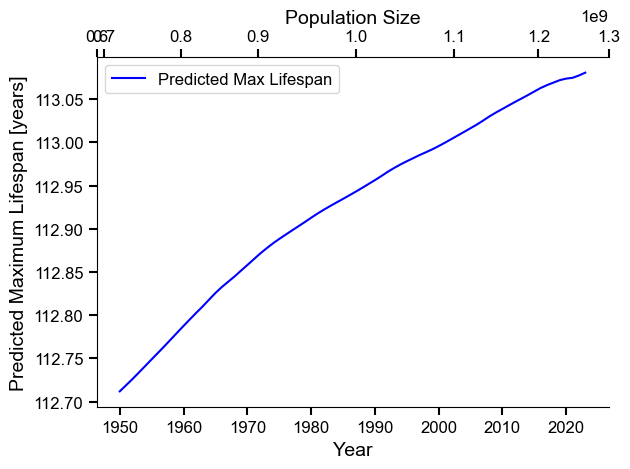

In [86]:
plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots()

# Plot predicted maximum lifespan vs year
ax.plot(years, predict_max_lifespan(pop), label='Predicted Max Lifespan', color='blue')

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Predicted Maximum Lifespan [years]', fontsize=14)
ax.legend(fontsize=12)

# Add a secondary x-axis on top for population size (log scale)
def years_to_pop(x):
    # x is years, map to pop using index
    idx = np.searchsorted(years, x)
    idx = np.clip(idx, 0, len(pop)-1)
    return pop[idx]

def pop_to_years(x):
    # x is pop, map to years using index
    idx = np.searchsorted(pop, x)
    idx = np.clip(idx, 0, len(years)-1)
    return years[idx]

secax = ax.secondary_xaxis('top', functions=(years_to_pop, pop_to_years))
secax.set_xlabel('Population Size', fontsize=14)

plt.tight_layout()
plt.show()

Wrote: developed_components_1830_2000.csv, developed_total_1830_2000.csv, developed_pop_1830_2000.[png|svg]


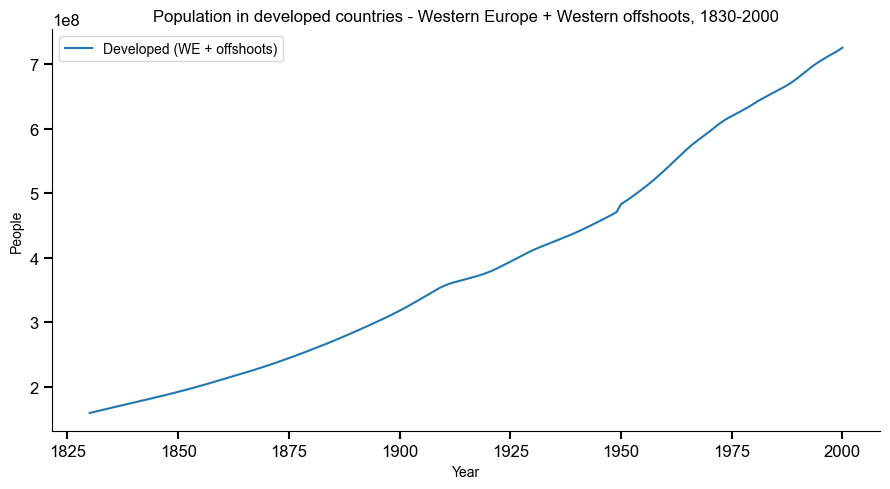

In [89]:
# Python 3.9+, pandas, matplotlib, requests
import io, requests, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---- 1) Maddison region mapping ----
map_url = "https://ourworldindata.org/grapher/world-regions-according-to-maddison-project-database.csv"
m = pd.read_csv(io.StringIO(requests.get(map_url, timeout=60).text))

# Find the mapping column name programmatically
meta = {"Entity","Code","Year"}
cand = [c for c in m.columns if c not in meta]
if not cand:
    raise ValueError(f"No mapping column found. Columns: {m.columns.tolist()}")
mapcol = cand[0]

# Keep latest mapping per Entity - mapping is time-invariant for our purpose
m = m.sort_values(["Entity","Year"]).drop_duplicates(subset=["Entity"], keep="last")[["Entity", mapcol]]
m = m.rename(columns={mapcol: "MaddisonRegion"})

we_countries = set(m.loc[m["MaddisonRegion"]=="Western Europe","Entity"])
wo_countries = set(m.loc[m["MaddisonRegion"]=="Western offshoots","Entity"])
assert we_countries and wo_countries, "Could not resolve Western Europe or Western offshoots from mapping."

# ---- 2) Country population ----
pop_url = "https://ourworldindata.org/grapher/population.csv"
p = pd.read_csv(io.StringIO(requests.get(pop_url, timeout=90).text))

# Detect population value column
valcol = next(c for c in p.columns if c.lower().startswith("pop") and c not in {"Population density"})

# Keep only country rows (have a 3-letter ISO code)
p = p[p["Code"].str.len()==3]

# Restrict years
p = p[(p["Year"]>=1830) & (p["Year"]<=2000)]

# ---- 3) Build component series ----
we = p[p["Entity"].isin(we_countries)].groupby("Year")[valcol].sum().rename("Western Europe")
wo = p[p["Entity"].isin(wo_countries)].groupby("Year")[valcol].sum().rename("Western offshoots")

# Align index and combine
components = pd.concat([we, wo], axis=1).sort_index()
components["Developed (WE + offshoots)"] = components["Western Europe"] + components["Western offshoots"]

# ---- 4) Save CSVs ----
Path(".").mkdir(exist_ok=True, parents=True)
components.reset_index()[["Year","Western Europe","Western offshoots"]].to_csv(
    "../../saved_results/csv/developed_components_1830_2000.csv", index=False)
components.reset_index()[["Year","Developed (WE + offshoots)"]].to_csv(
    "../../saved_results/csv/developed_total_1830_2000.csv", index=False)

# ---- 5) Plot ----
plt.figure(figsize=(9,5))
plt.plot(components.index, components["Developed (WE + offshoots)"], label="Developed (WE + offshoots)")
plt.title("Population in developed countries - Western Europe + Western offshoots, 1830-2000")
plt.xlabel("Year"); plt.ylabel("People"); plt.legend(); plt.tight_layout()
plt.savefig("../../saved_results/cache/plots/developed_pop_1830_2000.png", dpi=200)
plt.savefig("developed_pop_1830_2000.svg")

print("Wrote: developed_components_1830_2000.csv, developed_total_1830_2000.csv, developed_pop_1830_2000.[png|svg]")

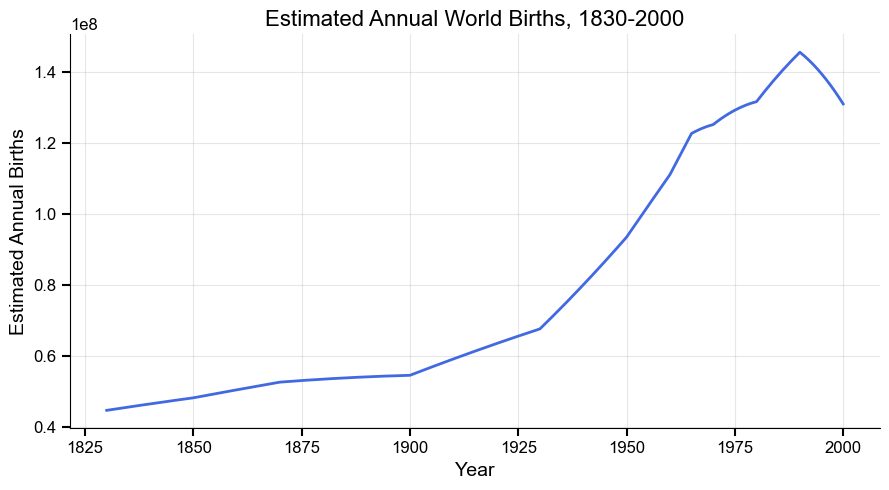

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load world_births_1830_2000_estimated.csv
births_df = pd.read_csv("../../saved_data/world_births_1830_2000_estimated.csv")
# The first row is a comment, so skip it
# Extract years and estimated births
years_births = births_df['year'].values
births_estimated = births_df['births_estimated'].values




plt.figure(figsize=(9, 5))
plt.plot(years_births, births_estimated, color='royalblue', linewidth=2)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Estimated Annual Births', fontsize=14)
plt.title('Estimated Annual World Births, 1830-2000', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

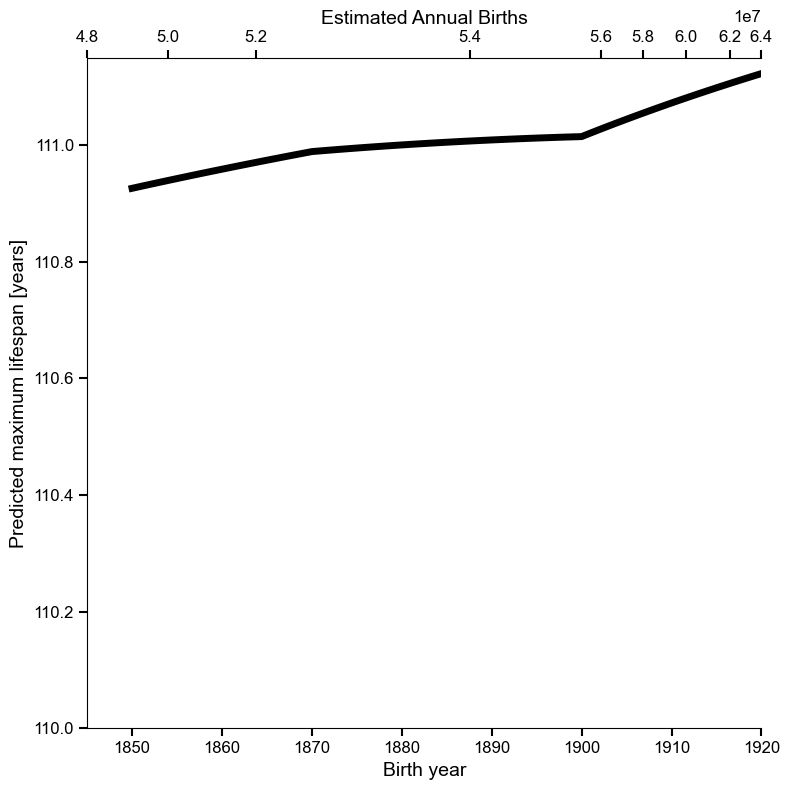

In [91]:
# Only consider years from 1830 to 1920
mask_1830_1920 = (years_births >= 1850) & (years_births <= 1920)
years_births_1830_1920 = years_births[mask_1830_1920]
births_estimated_1830_1920 = births_estimated[mask_1830_1920]
max_lifespan_births_1830_1920 = predict_max_lifespan(births_estimated_1830_1920)

plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(8,8))
# Plot predicted maximum lifespan vs year for 1830-1920
ax.plot(years_births_1830_1920, max_lifespan_births_1830_1920, color='black', linewidth=5)

ax.set_xlabel('Birth year', fontsize=14)
ax.set_ylabel('Predicted maximum lifespan [years]', fontsize=14)
ax.set_xlim(1845, 1920)
ax.set_ylim(110,111.15)

# Set y-axis ticks to every 0.05
from matplotlib.ticker import MultipleLocator
ax.yaxis.set_major_locator(MultipleLocator(0.2))

# Add a secondary x-axis on top for number of births (1830-1920)
def years_to_births(x):
    # Interpolate: given year(s), return corresponding birth count(s)
    return np.interp(x, years_births_1830_1920, births_estimated_1830_1920)

def births_to_years(x):
    # Interpolate: given birth count(s), return corresponding year(s)
    # Note: This works best if births are roughly monotonic
    return np.interp(x, births_estimated_1830_1920, years_births_1830_1920)

secax = ax.secondary_xaxis('top', functions=(years_to_births, births_to_years))
secax.set_xlabel('Estimated Annual Births', fontsize=14)

plt.tight_layout()
plt.show()

### around a quarter of those were in the "developed" world so lets go with 1e7 births

# Creating sims and saving results

In [ ]:
import model_param_calibrations as mcal
factors = np.arange(1, 1.61, 0.05)
n_sim = int(1e7)
n_repeats = 1

# Storage for results by distribution type
results_by_dist = {}

for dist_type in ['gaussian', 'lognormal']:
    print(f"\n{'='*60}")
    print(f"Processing distribution: {dist_type}")
    print(f"{'='*60}")
    
    # Storage for results
    factor_results = []

    for factor in factors:
        print(f"\nProcessing factor {factor:.2f}")
        
        # Storage for this factor's repeats - store top 1000 from each repeat
        top_1000_by_repeat = []
        top_1000_Xc_by_repeat = []
        
        for repeat in range(n_repeats):
            # Setup parameters
            danish_dict = mcal.sr_denmark_dict.copy()
            danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']
            
            # Adjust Xc
            danish_dict['Xc'] = 0.85 * danish_dict['Xc']
            danish_dict['Xc'] = factor * danish_dict['Xc']
            
            # Create parameter distributions
            danish_param_dist = utils.create_param_distribution_dict(
                params_dict=danish_dict,
                params='Xc',
                std=danish_Xc_std,
                n=n_sim,
                family='None',
                dist_type=dist_type
            )
            
            # Simulate
            hum_sim = utils.create_sr_simulation(params_dict=danish_param_dist, n=n_sim, parallel = True)
            
            # Get death times and corresponding Xc values
            valid_mask = hum_sim.death_times <= 130
            death_times = hum_sim.death_times[valid_mask]
            Xc_values = hum_sim.params.Xc[valid_mask]
            
            # Get indices of top 1000 longest lived
            top_1000_indices = np.argsort(death_times)[-1000:][::-1]  # Reverse to get oldest first
            
            # Get top 1000 death times and their corresponding Xc values
            top_1000 = death_times[top_1000_indices]
            top_1000_Xc = Xc_values[top_1000_indices]
            
            top_1000_by_repeat.append(top_1000)
            top_1000_Xc_by_repeat.append(top_1000_Xc)
            
            print(f"  Repeat {repeat+1}: top lifespan = {top_1000[0]:.2f}, Xc = {top_1000_Xc[0]:.4f}")
        
        # Convert to arrays: shape (n_repeats, 1000)
        top_1000_array = np.array(top_1000_by_repeat)
        top_1000_Xc_array = np.array(top_1000_Xc_by_repeat)
        
        # Average over repeats for each rank: shape (1000,)
        top_1000_averaged = np.mean(top_1000_array, axis=0)
        top_1000_Xc_averaged = np.mean(top_1000_Xc_array, axis=0)
        
        # Calculate SEM for each rank: shape (1000,)
        top_1000_sem = np.std(top_1000_array, axis=0, ddof=1) / np.sqrt(n_repeats)
        top_1000_Xc_sem = np.std(top_1000_Xc_array, axis=0, ddof=1) / np.sqrt(n_repeats)
        
        factor_results.append({
            'factor': factor,
            'top_1000_averaged': top_1000_averaged,  # Mean death time for each rank
            'top_1000_sem': top_1000_sem,  # SEM for each rank
            'top_1000_Xc_averaged': top_1000_Xc_averaged,  # Mean Xc for each rank
            'top_1000_Xc_sem': top_1000_Xc_sem  # SEM for Xc at each rank
        })
        
        print(f"Factor {factor:.2f}: mean oldest = {top_1000_averaged[0]:.2f} ± {top_1000_sem[0]:.2f}, Xc = {top_1000_Xc_averaged[0]:.4f} ± {top_1000_Xc_sem[0]:.4f}")

    # Extract results
    factors_array = np.array([r['factor'] for r in factor_results])

    # Store results for this distribution
    results_by_dist[dist_type] = {
        'factors': factors_array,
        'n_sim': n_sim,
        'n_repeats': n_repeats,
        'distribution': dist_type,
        'factor_results': factor_results  # Contains top_1000_averaged, top_1000_sem, top_1000_Xc_averaged, and top_1000_Xc_sem arrays
    }

# Plot results
plt.rcParams['font.family'] = 'Arial'

# Save results to pickle
import pickle

# Create saved_results directory if it doesn't exist
os.makedirs('saved_results', exist_ok=True)

# Create descriptive filename
pickle_filename = f'saved_results/max_lifespan_Xc_factors_{factors_array.min():.2f}to{factors_array.max():.2f}_top1000_n{n_sim}_repeats{n_repeats}_both_dists.pkl'

# Save combined results dictionary
with open(pickle_filename, 'wb') as f:
    pickle.dump(results_by_dist, f)

print(f"\nResults saved to {pickle_filename}")
print(f"Distributions included: {list(results_by_dist.keys())}")

# For backward compatibility, extract means and SEMs from the first distribution
first_dist = list(results_by_dist.keys())[0]
means_array = np.array([r['top_1000_averaged'][0] for r in results_by_dist[first_dist]['factor_results']])
sems_array = np.array([r['top_1000_sem'][0] for r in results_by_dist[first_dist]['factor_results']])
factors_array = results_by_dist[first_dist]['factors']



Processing distribution: gaussian

Processing factor 1.00
  Repeat 1: top lifespan = 110.28
Factor 1.00: mean oldest = 110.28 ± nan

Processing factor 1.05


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Repeat 1: top lifespan = 112.58
Factor 1.05: mean oldest = 112.58 ± nan

Processing factor 1.10


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Repeat 1: top lifespan = 113.48
Factor 1.10: mean oldest = 113.48 ± nan

Processing factor 1.15


...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Repeat 1: top lifespan = 117.70
Factor 1.45: mean oldest = 117.70 ± nan

Processing factor 1.50


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Repeat 1: top lifespan = 117.28
Factor 1.50: mean oldest = 117.28 ± nan

Results saved to saved_results/max_lifespan_Xc_factors_1.00to1.50_top1000_n10000000_repeats1_both_dists.pkl
Distributions included: ['gaussian', 'lognormal']


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


# roughly 50% increase in Xc threshold parameter worldwide from 1850 to 1900 

In [103]:
# Load the go-with-winners results from pickle
import pickle

pickle_filename_gw = 'saved_results/go_with_ww_max_lifespan_factors_1.00to1.50_top100_n10000000_repeats50.pkl'

with open(pickle_filename_gw, 'rb') as f:
    gw_results = pickle.load(f)

# Extract the sorted list of factors (ascending order), skipping only the very last, which may be corrupt
factors_gw_all = sorted(gw_results.keys())
factors_gw = factors_gw_all[:-1]  # Exclude the final factor, something is messed up

# Now get the means and SEMs for these factors (exclude the final factor that might be corrupt)
rank1_means_gw = np.array([gw_results[f]['sim_means'][1] for f in factors_gw])
rank1_sems_gw = np.array([gw_results[f]['sim_sems'][1] for f in factors_gw])



# Da Plot


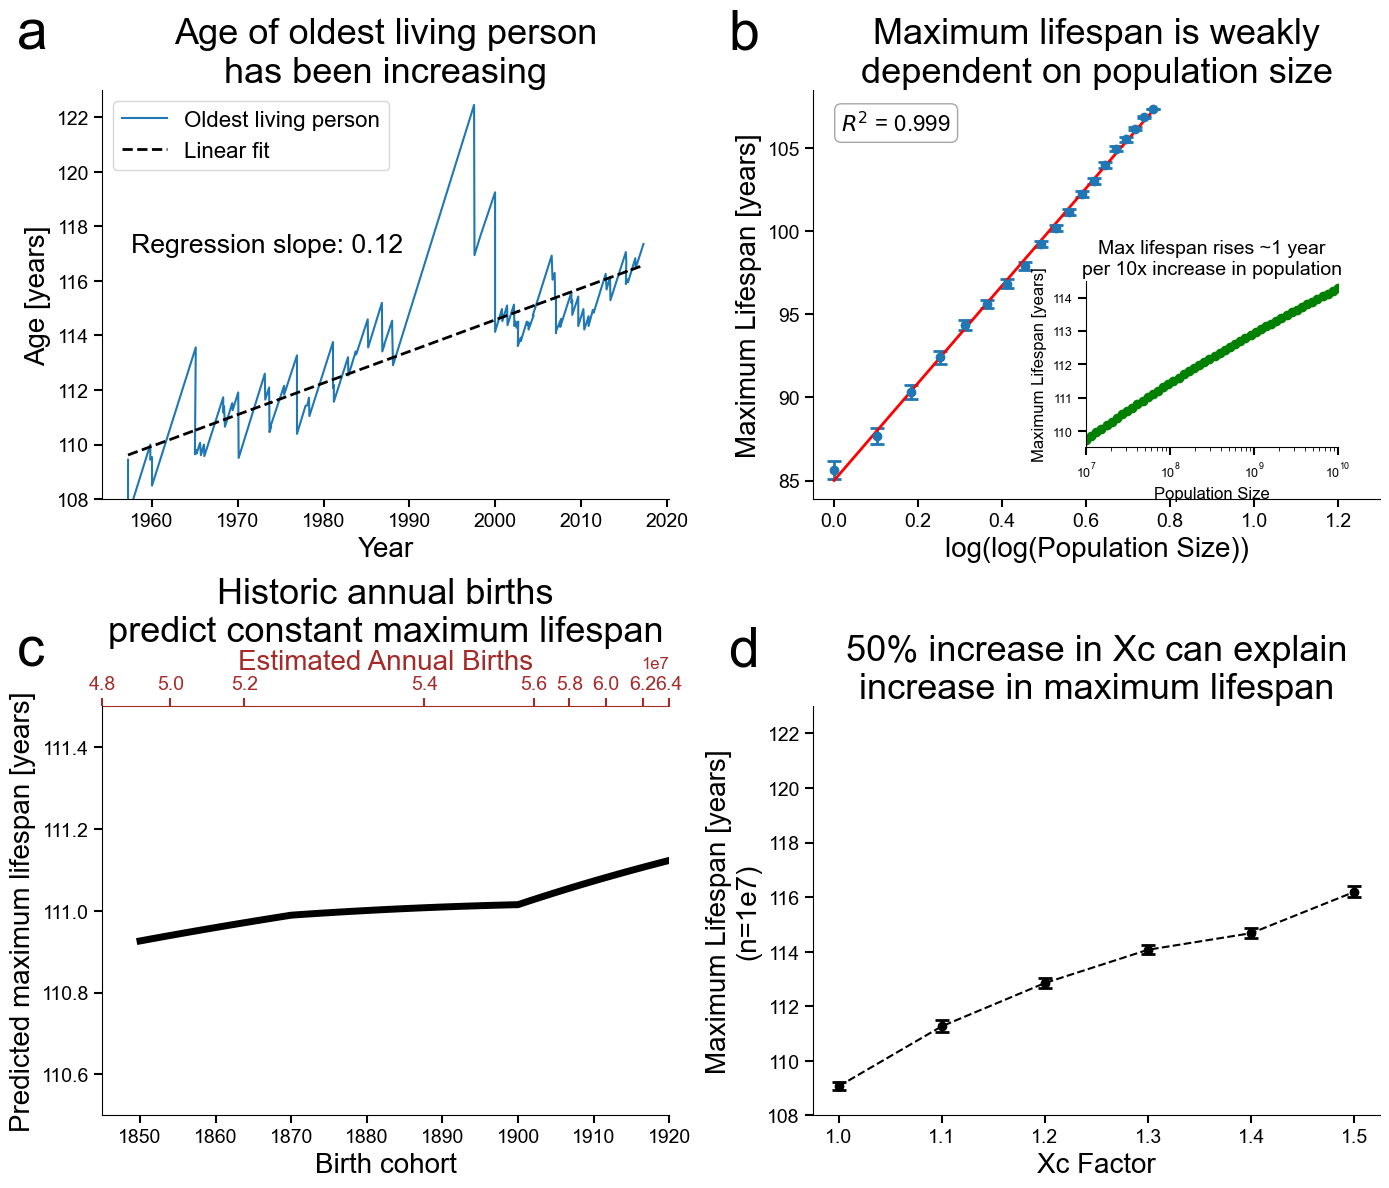

In [115]:
# Define formatting options
plt.rcParams['font.family'] = 'Arial'
label_size = 20
tick_size = 14
panel_label_size = 40
legend_size = 16
title_size = 26

# Create 2x2 grid
fig, ((ax_a, ax_b), (ax_c, ax_d)) = plt.subplots(2, 2, figsize=(14, 12))

# --- Panel a: Oldest living person data with linear fit (was c) ---
df = pd.read_csv('saved_results/oldest_living_person.csv')
df.columns = ['year', 'oldest']

# Fit linear trend line
z = np.polyfit(df['year'], df['oldest'], 1)
p = np.poly1d(z)

ax_a.plot(df['year'], df['oldest'], label='Oldest living person')
ax_a.plot(df['year'], p(df['year']), 'k--', linewidth=2, label='Linear fit')
ax_a.set_xlabel('Year', fontsize=label_size, fontfamily='Arial')
ax_a.set_ylabel('Age [years]', fontsize=label_size, fontfamily='Arial')
ax_a.set_ylim(108, 123)
ax_a.tick_params(labelsize=tick_size)
ax_a.legend(fontsize=legend_size, prop={'family': 'Arial', 'size': legend_size})
equation_text = f'Regression slope: {z[0]:.2f}'
ax_a.text(0.05, 0.65, equation_text, transform=ax_a.transAxes, 
          fontsize=legend_size*1.2, verticalalignment='top',
          fontfamily='Arial')

# --- Panel b: Maximum Lifespan vs Population Size with regression (was a) ---
ax_b.errorbar(x_array, y_array, yerr=yerr_array, 
              marker='o', capsize=5, capthick=2, linewidth=2, label='Data', linestyle='None')

# Plot regression line
x_fit = np.linspace(x_array.min(), x_array.max(), 100)
y_fit = reg.predict(x_fit.reshape(-1, 1))
ax_b.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear Fit')

# Calculate R² for the fit
r2_full = reg.score(x_array.reshape(-1, 1), y_array)

r2_text = f"$R^2$ = {r2_full:.3f}"
ax_b.text(0.05, 0.95, r2_text, transform=ax_b.transAxes, fontsize=legend_size, 
          verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
          fontfamily='Arial')

ax_b.set_xlabel('log(log(Population Size))', fontsize=label_size, fontfamily='Arial')
ax_b.set_ylabel('Maximum Lifespan [years]', fontsize=label_size, fontfamily='Arial')
ax_b.tick_params(labelsize=tick_size)
ax_b.set_xlim(-0.05, 1.3)

# Create inset axes for panel b using data coordinates
inset_bbox = [0.6, 87, 0.6, 10]  # x from 0.5 to 0.9, y from 100 to 115
ax_inset = ax_b.inset_axes(inset_bbox, transform=ax_b.transData)

# Generate data for inset
pops_inset = np.logspace(7, 10, 50)
y_inset = predict_max_lifespan(pops_inset)

ax_inset.plot(pops_inset, y_inset, marker='o', linestyle='-', color='green')
ax_inset.set_xlim(1e7, 1e10)
ax_inset.text(0.5, 1.25, 'Max lifespan rises ~1 year\nper 10x increase in population', 
              transform=ax_inset.transAxes, fontsize=14, ha='center', va='top', fontfamily='Arial')
ax_inset.set_xlabel('Population Size', fontsize=12, fontfamily='Arial')
ax_inset.set_ylabel('Maximum Lifespan [years]', fontsize=12, fontfamily='Arial')
ax_inset.tick_params(labelsize=9)
ax_inset.set_xscale('log')

# --- Panel c: Predicted maximum lifespan vs birth year (1850-1920) (was b) ---
mask_1830_1920 = (years_births >= 1850) & (years_births <= 1920)
years_births_1830_1920 = years_births[mask_1830_1920]
births_estimated_1830_1920 = births_estimated[mask_1830_1920]
max_lifespan_births_1830_1920 = predict_max_lifespan(births_estimated_1830_1920)

ax_c.plot(years_births_1830_1920, max_lifespan_births_1830_1920, color='black', linewidth=5)

ax_c.set_xlabel('Birth cohort', fontsize=label_size, fontfamily='Arial')
ax_c.set_ylabel('Predicted maximum lifespan [years]', fontsize=label_size, fontfamily='Arial')
ax_c.set_xlim(1845, 1920)
ax_c.set_ylim(110.5, 111.5)
ax_c.tick_params(labelsize=tick_size)

from matplotlib.ticker import MultipleLocator
ax_c.yaxis.set_major_locator(MultipleLocator(0.2))

# Add a secondary x-axis on top for number of births (1850-1920)
def years_to_births(x):
    return np.interp(x, years_births_1830_1920, births_estimated_1830_1920)

def births_to_years(x):
    return np.interp(x, births_estimated_1830_1920, years_births_1830_1920)

secax_c = ax_c.secondary_xaxis('top', functions=(years_to_births, births_to_years))
secax_c.set_xlabel('Estimated Annual Births', fontsize=label_size, color='brown', fontfamily='Arial')
secax_c.tick_params(labelsize=tick_size, colors='brown')
secax_c.spines['top'].set_color('brown')

# --- Panel d: Effect of Xc Factor on Maximum Lifespan (unchanged) ---
ax_d.errorbar(factors_gw, rank1_means_gw, yerr=rank1_sems_gw, 
              fmt='o--', color='black', markersize=6,
              capsize=5, capthick=2, label='Data')

ax_d.set_xlabel('Xc Factor', fontsize=label_size, fontfamily='Arial')
ax_d.set_ylabel('Maximum Lifespan [years]\n(n=1e7)', fontsize=label_size, fontfamily='Arial')
ax_d.set_ylim(108, 123)
ax_d.tick_params(labelsize=tick_size)

# --- Titles and Labels ---
ax_a.set_title('Age of oldest living person\nhas been increasing', fontsize=title_size, fontfamily='Arial')
ax_b.set_title('Maximum lifespan is weakly\ndependent on population size', fontsize=title_size, fontfamily='Arial')
ax_c.set_title('Historic annual births\npredict constant maximum lifespan', fontsize=title_size, fontfamily='Arial')
ax_d.set_title('50% increase in Xc can explain\nincrease in maximum lifespan', fontsize=title_size, fontfamily='Arial')

ax_a.text(-0.15, 1.1, 'a', transform=ax_a.transAxes, fontsize=panel_label_size, fontfamily='Arial')
ax_b.text(-0.15, 1.1, 'b', transform=ax_b.transAxes, fontsize=panel_label_size, fontfamily='Arial')
ax_c.text(-0.15, 1.1, 'c', transform=ax_c.transAxes, fontsize=panel_label_size, fontfamily='Arial')
ax_d.text(-0.15, 1.1, 'd', transform=ax_d.transAxes, fontsize=panel_label_size, fontfamily='Arial')

plt.tight_layout()
fig.savefig("Figures/max_lifespan.pdf", format="pdf")
